# Temporal sEEG graph from an EDF file (Google Colab)

This notebook loads `dataset/sEEG-HFOs-8.edf`, removes marker channels named `MKR<i>` (for example, `MKR1`), splits every retained sEEG channel into consecutive **2-second windows**, and builds one sparse NetworkX graph per window.

- **Nodes:** channels, with `db4` discrete-wavelet energy and signal-statistic features.
- **Edges:** signed correlations between multiscale `db4` coefficient vectors. Weak correlations are removed, and per-node top-*k* pruning prevents dense graphs.
- **Temporal output:** dense node-feature tensors plus sparse edge tensors, saved with PyTorch.
- **Known event:** the 808–810 s window and channels `CC'4`, `CC'5`, and `CR'5` are explicitly annotated and visualized. The annotation does not alter measured correlations.

> Google Colab is Linux-based. A path written locally as `\dataset\sEEG-HFOs-8.edf` corresponds to `/content/dataset/sEEG-HFOs-8.edf` after upload.


In [1]:
# Install analysis dependencies into the Colab runtime.
%pip install -q mne edfio PyWavelets networkx seaborn ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 116.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import mne
import networkx as nx
import numpy as np
import pandas as pd
import pywt
import seaborn as sns
import torch
from IPython.display import display

mne.set_log_level("WARNING")
np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.figsize": (14, 7), "axes.grid": False})


## Configuration

`CORRELATION_THRESHOLD` removes weak edges. `TOP_K_PER_NODE` then retains only each node's strongest candidates (the union of those selections), preserving all nodes even if a node becomes isolated. Adjust these two values if the graphs are too dense or sparse.


In [29]:
WINDOW_SECONDS = 2.0
WAVELET = "db4"
CORRELATION_THRESHOLD = 0.65
TOP_K_PER_NODE = 6
KNOWN_EVENT_INTERVAL = (808.0, 810.0)
KNOWN_EVENT_CHANNELS = ("EEG CC'4", "EEG CC'5", "EEG CR'5")
OUTPUT_DIR = Path("/content/seeg_graph_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert WINDOW_SECONDS == KNOWN_EVENT_INTERVAL[1] - KNOWN_EVENT_INTERVAL[0]
print(f"Outputs will be written to {OUTPUT_DIR}")

Outputs will be written to /content/seeg_graph_output


## Find and load the local EDF

Upload the file into a `dataset` directory from Colab's **Files** panel. If needed, uncomment the upload cell. Runtime uploads are temporary.


In [8]:
# Optional browser upload; uncomment when the dataset is not in /content/dataset.
# from google.colab import files
# uploaded = files.upload()
# Path("/content/dataset").mkdir(parents=True, exist_ok=True)
# uploaded_name = next(iter(uploaded))
# Path(uploaded_name).replace(Path("/content/dataset/sEEG-HFOs-8.edf"))


In [9]:
candidates = [
    Path("/content/sEEG-HFOs-8.edf"),
    #Path("dataset/sEEG-HFOs-8.edf"),
]
edf_path = next((path for path in candidates if path.is_file()), None)
if edf_path is None:
    searched = "\n".join(f"  - {path.resolve()}" for path in candidates)
    raise FileNotFoundError(
        "sEEG-HFOs-8.edf was not found. Upload it with the cell above. "
        f"Searched:\n{searched}"
    )

raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING")
duration_s = raw.n_times / raw.info["sfreq"]
print(f"Loaded {edf_path.resolve()}")
print(f"{len(raw.ch_names)} channels, {raw.info['sfreq']:.3f} Hz, {duration_s:.2f} s")


Loaded /content/sEEG-HFOs-8.edf
102 channels, 256.000 Hz, 5089.00 s


/tmp/ipykernel_1689/1453920653.py:13: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING")
/tmp/ipykernel_1689/1453920653.py:13: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose="WARNING")


## Keep sEEG channels and exclude `MKR<i>` markers

The regular expression is case-insensitive and accepts optional whitespace between `MKR` and its numeric index. The channel order from the EDF is preserved.


In [24]:
print("EEG Channels from EDF:")
for channel in seeg_channels:
    print(channel)

EEG Channels from EDF:
EEG R1
EEG R2
EEG R3
EEG R4
EEG R5
EEG R6
EEG R7
EEG R8
EEG R9
EEG R10
EEG FP1
EEG FP2
EEG FP3
EEG FP4
EEG FP5
EEG FP6
EEG FP7
EEG FP8
EEG FD1
EEG FD2
EEG FD3
EEG FD4
EEG FD5
EEG FD6
EEG PM1
EEG PM2
EEG PM3
EEG PM4
EEG PM5
EEG PM6
EEG PM7
EEG PM8
EEG CC1
EEG CC2
EEG CC3
EEG CC4
EEG CC5
EEG CC6
EEG CC7
EEG CC8
EEG CC9
EEG CC10
EEG SA1
EEG SA2
EEG SA3
EEG SA4
EEG SA5
EEG SA6
EEG PA1
EEG PA2
EEG PA3
EEG PA4
EEG PA5
EEG PA6
EEG PA7
EEG PA8
EEG PA9
EEG PA10
EEG CR'1
EEG CR'2
EEG CR'3
EEG CR'4
EEG CR'5
EEG CR'6
EEG CR'7
EEG CR'8
EEG CR'9
EEG CR'10
EEG CC'1
EEG CC'2
EEG CC'3
EEG CC'4
EEG CC'5
EEG CC'6
EEG CC'7
EEG CC'8
EEG CC'9
EEG CC'10
EEG PM'1
EEG PM'2
EEG PM'3
EEG PM'4
EEG PM'5
EEG PM'6
EEG SA'1
EEG SA'2
EEG SA'3
EEG SA'4
EEG SA'5
EEG SA'6
EEG SA'7
EEG SA'8
EEG PA'1
EEG PA'2
EEG PA'3
EEG PA'4
EEG PA'5
EEG PA'6
EEG PA'7
EEG PA'8


In [25]:
marker_pattern = re.compile(r"^MKR\s*\d+\+?$", flags=re.IGNORECASE)
marker_channels = [name for name in raw.ch_names if marker_pattern.fullmatch(name.strip())]
seeg_channels = [name for name in raw.ch_names if name not in marker_channels]
if not seeg_channels:
    raise ValueError("No non-marker channels remain after excluding MKR<i> channels.")

missing_event_channels = [name for name in KNOWN_EVENT_CHANNELS if name not in seeg_channels]
channel_table = pd.DataFrame({
    "channel_index": range(len(seeg_channels)),
    "channel": seeg_channels,
    "known_808_810_event_channel": [name in KNOWN_EVENT_CHANNELS for name in seeg_channels],
})
print(f"Excluded {len(marker_channels)} marker channels: {marker_channels}")
print(f"Retained {len(seeg_channels)} channels")
if missing_event_channels:
    print("WARNING: expected event channels absent from EDF:", missing_event_channels)
display(channel_table)

Excluded 2 marker channels: ['MKR1+', 'MKR2+']
Retained 100 channels


,channel_index,channel,known_808_810_event_channel
0,0,EEG R1,False
1,1,EEG R2,False
2,2,EEG R3,False
3,3,EEG R4,False
4,4,EEG R5,False
...,...,...,...
95,95,EEG PA'4,False
96,96,EEG PA'5,False
97,97,EEG PA'6,False
98,98,EEG PA'7,False


## Wavelet features and correlation graph

For each channel/window, `pywt.wavedec` produces the maximum valid decomposition (capped at level 5). Node features contain log-energy for the approximation and every detail band, followed by mean, standard deviation, RMS, and line length. All windows have the same feature width because their sample counts are fixed.

Edge correlation is computed between concatenated, independently standardized wavelet subbands. This prevents a high-energy band from dominating the correlation while retaining multiscale waveform information. The sparse graph stores both signed `correlation` and `abs_correlation`.


In [12]:
def wavelet_representation(signal, wavelet=WAVELET, max_level=5):
    signal = np.asarray(signal, dtype=np.float64)
    wavelet_obj = pywt.Wavelet(wavelet)
    valid_level = pywt.dwt_max_level(len(signal), wavelet_obj.dec_len)
    level = min(max_level, valid_level)
    if level < 1:
        raise ValueError(
            f"A {len(signal)}-sample window is too short for the {wavelet} wavelet."
        )

    coefficients = pywt.wavedec(signal, wavelet_obj, level=level, mode="symmetric")
    log_energies = [np.log1p(np.mean(np.square(band))) for band in coefficients]
    statistics = [
        np.mean(signal),
        np.std(signal),
        np.sqrt(np.mean(np.square(signal))),
        np.mean(np.abs(np.diff(signal))),
    ]
    features = np.asarray(log_energies + statistics, dtype=np.float32)

    standardized_bands = []
    for band in coefficients:
        scale = np.std(band)
        standardized_bands.append((band - np.mean(band)) / (scale + 1e-12))
    correlation_vector = np.concatenate(standardized_bands)
    return features, correlation_vector, level


def prune_correlations(correlation, threshold, top_k):
    # Return undirected (i, j, signed correlation) edges after threshold/top-k pruning.
    n_nodes = correlation.shape[0]
    magnitude = np.abs(correlation)
    np.fill_diagonal(magnitude, 0.0)
    selected = set()
    for node in range(n_nodes):
        candidates = np.flatnonzero(magnitude[node] >= threshold)
        if candidates.size:
            strongest = candidates[np.argsort(magnitude[node, candidates])[-top_k:]]
            selected.update(tuple(sorted((node, int(other)))) for other in strongest if other != node)
    return [(i, j, float(correlation[i, j])) for i, j in sorted(selected)]


def build_window_graph(window_data, channel_names, start_s):
    node_features, wavelet_vectors = [], []
    decomposition_level = None
    for signal in window_data:
        features, vector, decomposition_level = wavelet_representation(signal)
        node_features.append(features)
        wavelet_vectors.append(vector)

    node_features = np.stack(node_features)
    correlation = np.corrcoef(np.stack(wavelet_vectors))
    correlation = np.nan_to_num(correlation, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(correlation, 1.0)
    edges = prune_correlations(correlation, CORRELATION_THRESHOLD, TOP_K_PER_NODE)

    graph = nx.Graph(
        window_start_s=float(start_s),
        window_end_s=float(start_s + WINDOW_SECONDS),
        known_extreme_event=(KNOWN_EVENT_INTERVAL[0] <= start_s < KNOWN_EVENT_INTERVAL[1]),
        wavelet=WAVELET,
        wavelet_level=decomposition_level,
    )
    for index, name in enumerate(channel_names):
        graph.add_node(
            name,
            index=index,
            features=node_features[index],
            known_event_channel=name in KNOWN_EVENT_CHANNELS,
        )
    for i, j, value in edges:
        graph.add_edge(
            channel_names[i], channel_names[j],
            correlation=value,
            abs_correlation=abs(value),
        )
    return graph, node_features, correlation


## Build the temporal graph, one 2-second window at a time

Only complete, non-overlapping windows are processed. NetworkX graphs are constructed for analysis, then converted immediately to sparse edge tensors so long recordings do not require retaining thousands of Python graph objects. The first graph and the known 808–810 s graph are retained for visualization.


In [13]:
sfreq = float(raw.info["sfreq"])
window_samples = int(round(WINDOW_SECONDS * sfreq))
n_windows = raw.n_times // window_samples
if n_windows == 0:
    raise ValueError("The EDF is shorter than one complete 2-second window.")
if duration_s < KNOWN_EVENT_INTERVAL[1]:
    raise ValueError(
        f"Recording ends at {duration_s:.2f} s, before the known 808–810 s event."
    )

event_window_index = int(KNOWN_EVENT_INTERVAL[0] // WINDOW_SECONDS)
node_feature_windows = []
edge_indices, edge_weights = [], []
window_start_seconds = []
first_graph = event_graph = None
first_correlation = event_correlation = None

for window_index in range(n_windows):
    start_sample = window_index * window_samples
    stop_sample = start_sample + window_samples
    start_s = start_sample / sfreq
    # MNE returns Volts; convert to microvolts before extracting scale-sensitive features.
    window_data = raw.get_data(
        picks=seeg_channels, start=start_sample, stop=stop_sample
    ) * 1e6
    graph, features, correlation = build_window_graph(window_data, seeg_channels, start_s)

    indexed_edges = [(graph.nodes[u]["index"], graph.nodes[v]["index"], data["correlation"])
                     for u, v, data in graph.edges(data=True)]
    if indexed_edges:
        pairs = torch.tensor([(i, j) for i, j, _ in indexed_edges], dtype=torch.long).T
        # Store both directions for graph-learning libraries.
        edge_index = torch.cat([pairs, pairs.flip(0)], dim=1)
        weights = torch.tensor([value for _, _, value in indexed_edges], dtype=torch.float32)
        edge_weight = torch.cat([weights, weights])
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_weight = torch.empty((0,), dtype=torch.float32)

    node_feature_windows.append(torch.from_numpy(features))
    edge_indices.append(edge_index)
    edge_weights.append(edge_weight)
    window_start_seconds.append(start_s)

    if window_index == 0:
        first_graph, first_correlation = graph.copy(), correlation.copy()
    if window_index == event_window_index:
        event_graph, event_correlation = graph.copy(), correlation.copy()
    if window_index % 100 == 0 or window_index == n_windows - 1:
        print(f"Processed {window_index + 1}/{n_windows} windows")

node_features = torch.stack(node_feature_windows).to(torch.float32)
window_start_seconds = torch.tensor(window_start_seconds, dtype=torch.float32)
print("Node feature tensor:", tuple(node_features.shape), "[window, channel, feature]")
print("Known event window index:", event_window_index,
      f"({window_start_seconds[event_window_index]:.1f}–{window_start_seconds[event_window_index] + WINDOW_SECONDS:.1f} s)")


Processed 1/2544 windows
Processed 101/2544 windows
Processed 201/2544 windows
Processed 301/2544 windows
Processed 401/2544 windows
Processed 501/2544 windows
Processed 601/2544 windows
Processed 701/2544 windows
Processed 801/2544 windows
Processed 901/2544 windows
Processed 1001/2544 windows
Processed 1101/2544 windows
Processed 1201/2544 windows
Processed 1301/2544 windows
Processed 1401/2544 windows
Processed 1501/2544 windows
Processed 1601/2544 windows
Processed 1701/2544 windows
Processed 1801/2544 windows
Processed 1901/2544 windows
Processed 2001/2544 windows
Processed 2101/2544 windows
Processed 2201/2544 windows
Processed 2301/2544 windows
Processed 2401/2544 windows
Processed 2501/2544 windows
Processed 2544/2544 windows
Node feature tensor: (2544, 102, 10) [window, channel, feature]
Known event window index: 404 (808.0–810.0 s)


## First-window heatmap and tensor

The full wavelet-correlation matrix is useful as a heatmap. The graph itself uses its thresholded/top-*k* sparse version. The first matrix is saved independently as a tensor as requested.


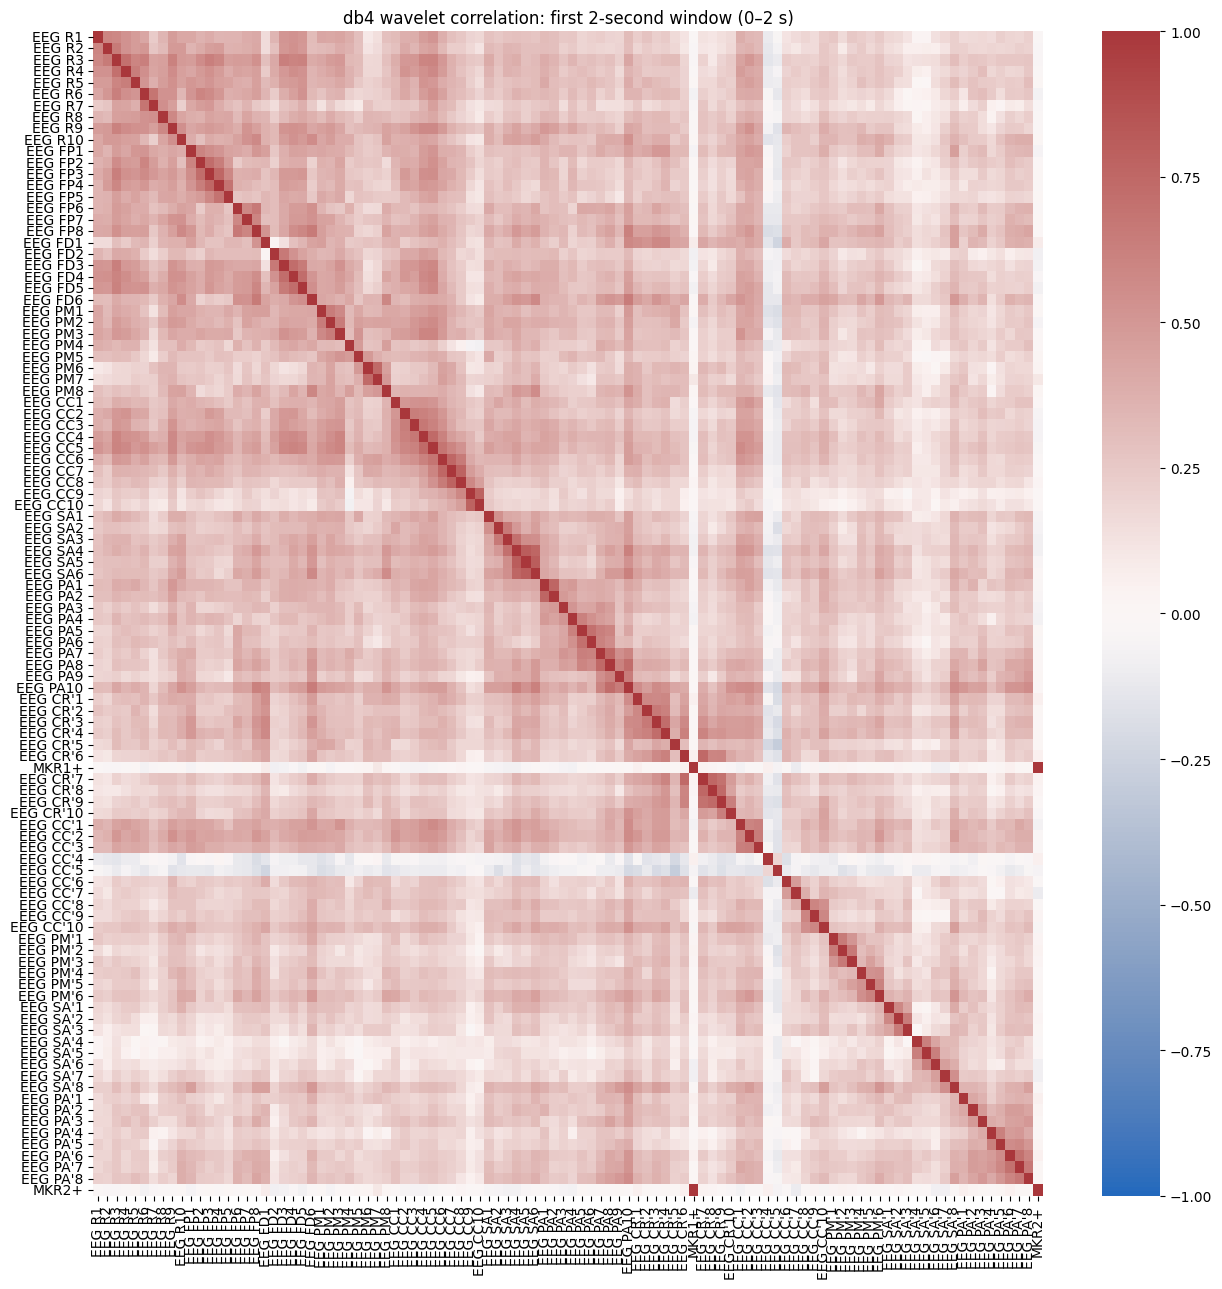

Saved: /content/seeg_graph_output/first_2s_wavelet_correlation.pt


In [15]:
first_heatmap_tensor = torch.from_numpy(first_correlation).to(torch.float32)
torch.save(first_heatmap_tensor, OUTPUT_DIR / "first_2s_wavelet_correlation.pt")

plt.figure(figsize=(13, 13))
sns.heatmap(
    first_heatmap_tensor.numpy(), cmap="vlag", center=0, vmin=-1, vmax=1,
    xticklabels=seeg_channels, yticklabels=seeg_channels,
)
plt.title("db4 wavelet correlation: first 2-second window (0–2 s)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "first_2s_wavelet_correlation_heatmap.png", dpi=180)
plt.show()
print("Saved:", OUTPUT_DIR / "first_2s_wavelet_correlation.pt")


## Explicitly inspect the known extreme event at 808–810 seconds

The temporal graph labels window 404 as `known_extreme_event=True`; the three specified nodes carry `known_event_channel=True`. The plots below compare the event correlation matrix with the first window and highlight the three channels in the NetworkX graph. These labels **annotate** the known event but never change node measurements or edge weights.


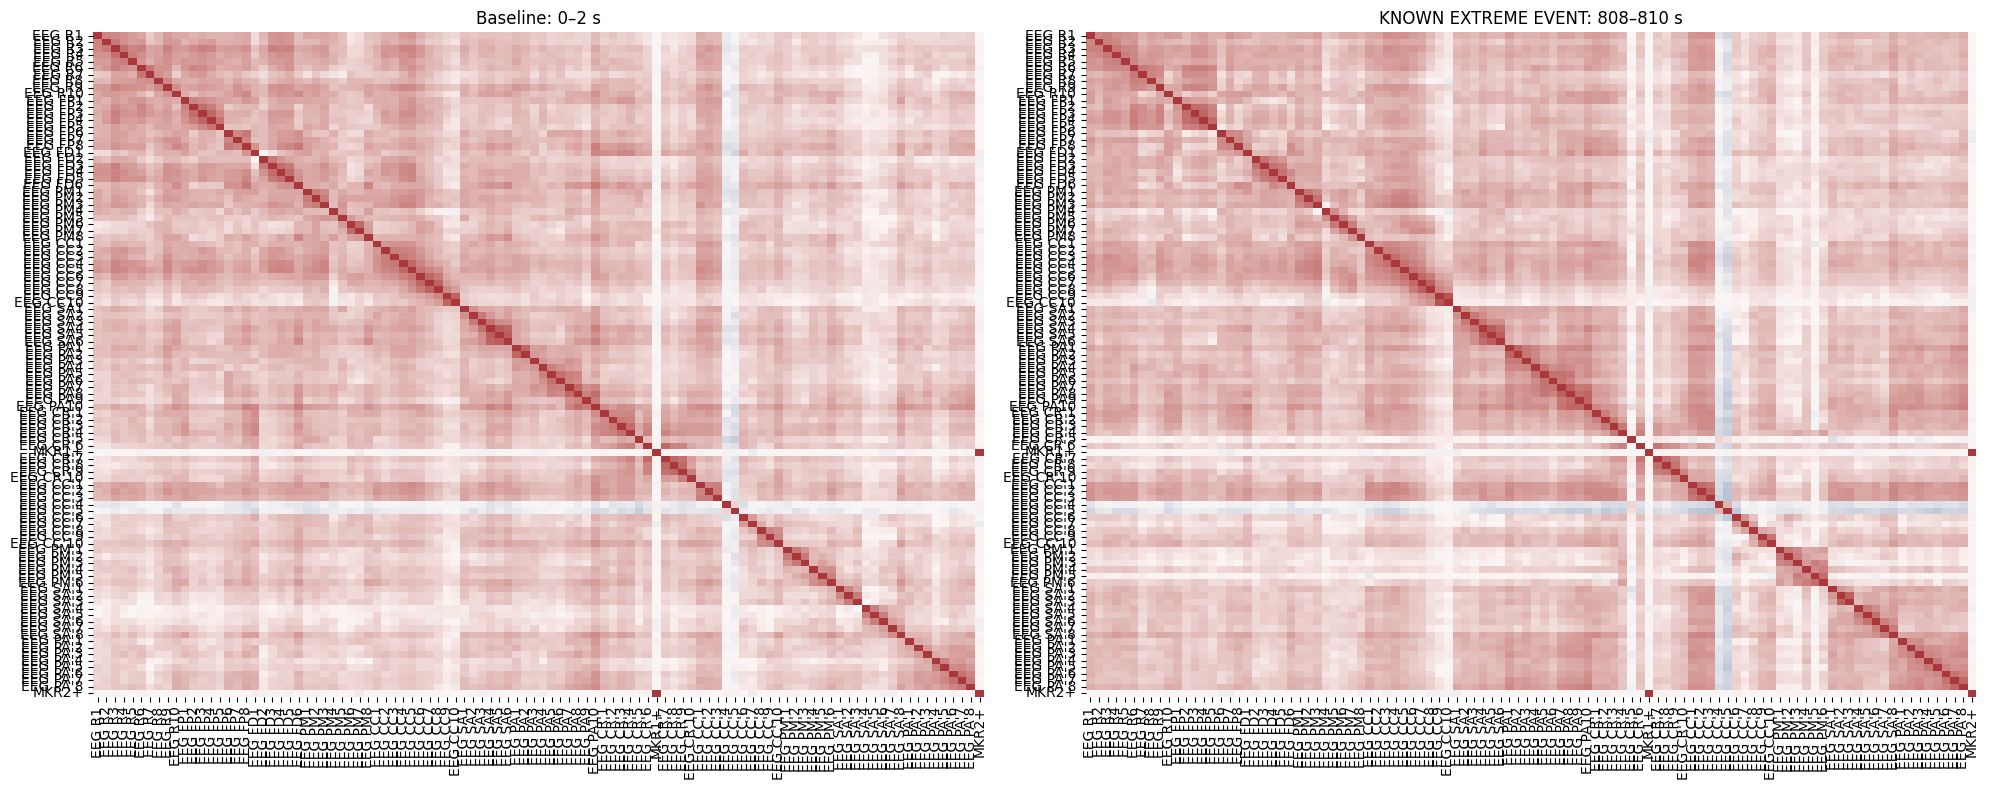

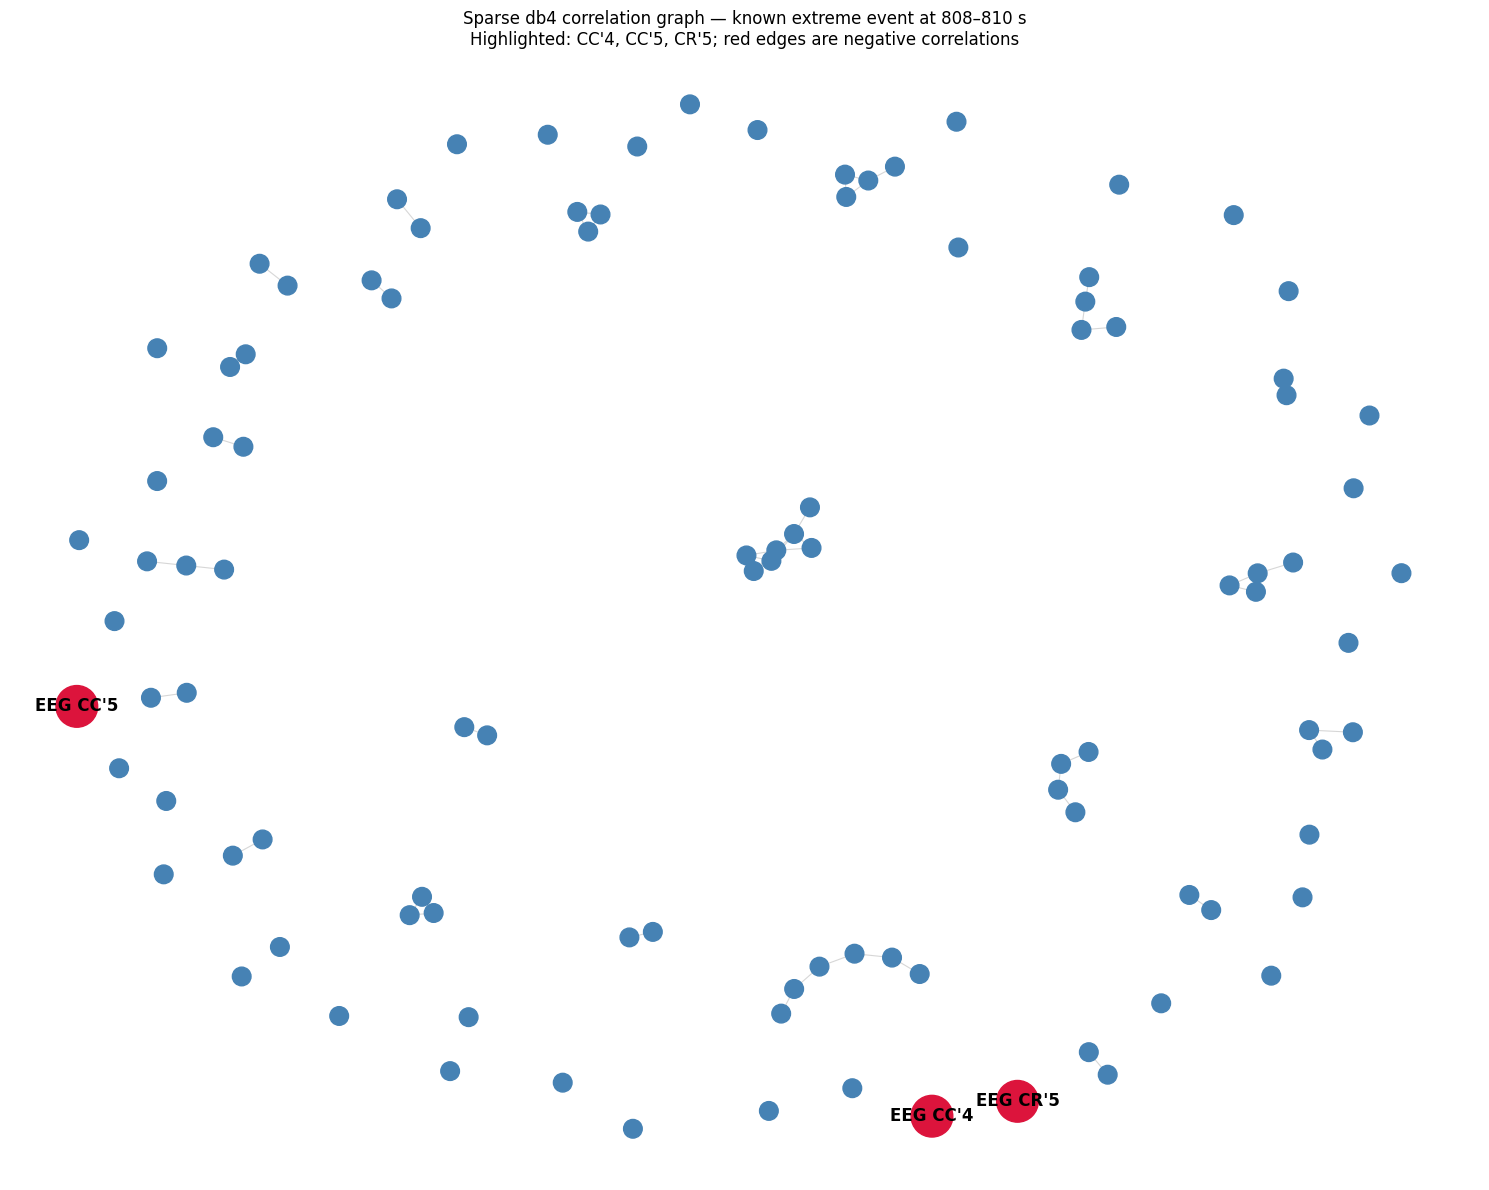

In [16]:
if event_graph is None:
    raise RuntimeError("The 808–810 s event graph was not captured.")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, matrix, title in [
    (axes[0], first_correlation, "Baseline: 0–2 s"),
    (axes[1], event_correlation, "KNOWN EXTREME EVENT: 808–810 s"),
]:
    sns.heatmap(matrix, cmap="vlag", center=0, vmin=-1, vmax=1,
                xticklabels=seeg_channels, yticklabels=seeg_channels, ax=ax, cbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_vs_808_810_heatmaps.png", dpi=180)
plt.show()

present_event_channels = [name for name in KNOWN_EVENT_CHANNELS if name in event_graph]
node_colors = ["crimson" if name in present_event_channels else "steelblue" for name in event_graph.nodes]
node_sizes = [900 if name in present_event_channels else 180 for name in event_graph.nodes]
edge_colors = ["firebrick" if data["correlation"] < 0 else "0.65"
               for _, _, data in event_graph.edges(data=True)]
pos = nx.spring_layout(event_graph, seed=7, weight="abs_correlation")
plt.figure(figsize=(15, 12))
nx.draw_networkx_edges(event_graph, pos, edge_color=edge_colors, alpha=0.45, width=0.8)
nx.draw_networkx_nodes(event_graph, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(event_graph, pos,
                        labels={name: name for name in present_event_channels},
                        font_weight="bold", font_color="black")
plt.title("Sparse db4 correlation graph — known extreme event at 808–810 s\n"
          "Highlighted: CC'4, CC'5, CR'5; red edges are negative correlations")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "extreme_event_808_810_graph.png", dpi=180)
plt.show()


## Quantify and preserve the extreme point

The event-score trace is derived from the data: it averages the detail-band log-energy features of the three known channels. A red marker makes 808–810 s structurally explicit even if another window happens to have a larger score. The printed percentile reports how extreme this known window is relative to the entire recording.


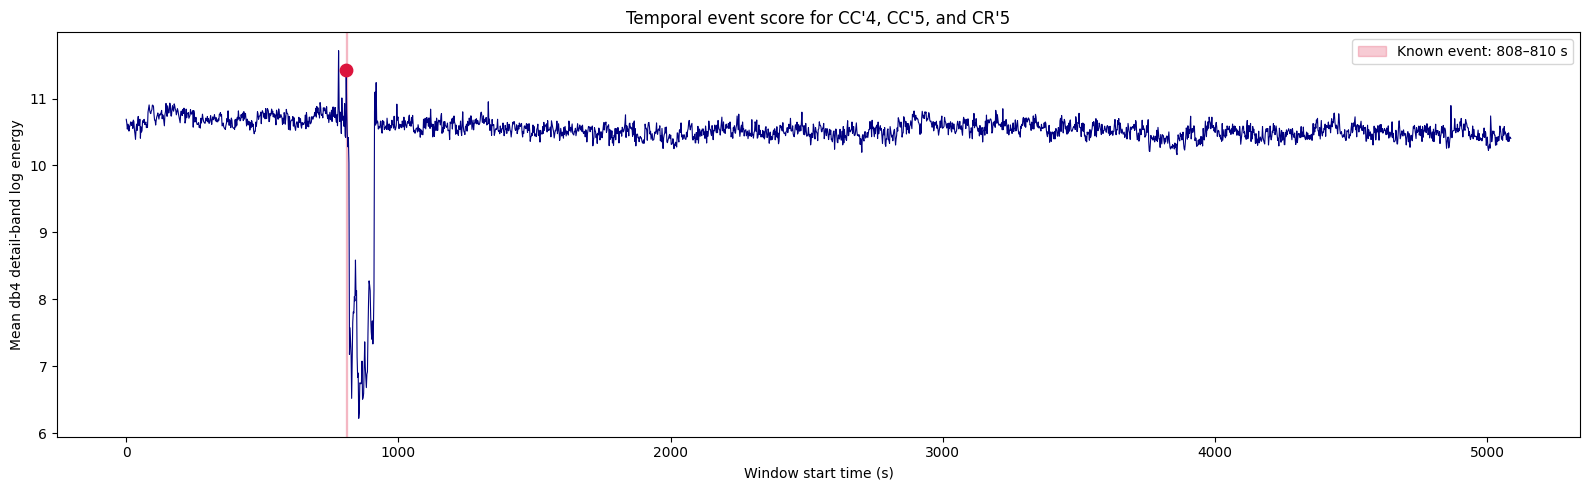

808–810 s event score: 11.4247 (percentile 99.96)


In [17]:
event_channel_indices = [seeg_channels.index(name) for name in KNOWN_EVENT_CHANNELS
                         if name in seeg_channels]
if not event_channel_indices:
    raise ValueError("None of the known event channels are present; cannot score the event.")

# Feature layout is [approximation energy, detail energies..., four statistics].
wavelet_energy_feature_count = node_features.shape[-1] - 4
detail_energy_slice = slice(1, wavelet_energy_feature_count)
event_score = node_features[:, event_channel_indices, detail_energy_slice].mean(dim=(1, 2))
known_score = event_score[event_window_index]
percentile = 100.0 * (event_score <= known_score).float().mean().item()

plt.figure(figsize=(16, 5))
plt.plot(window_start_seconds.numpy(), event_score.numpy(), linewidth=0.8, color="navy")
plt.axvspan(*KNOWN_EVENT_INTERVAL, color="crimson", alpha=0.22, label="Known event: 808–810 s")
plt.scatter([KNOWN_EVENT_INTERVAL[0]], [known_score.item()], color="crimson", s=80, zorder=3)
plt.xlabel("Window start time (s)")
plt.ylabel("Mean db4 detail-band log energy")
plt.title("Temporal event score for CC'4, CC'5, and CR'5")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "known_event_score_timeline.png", dpi=180)
plt.show()
print(f"808–810 s event score: {known_score.item():.4f} (percentile {percentile:.2f})")


## Save the temporal graph tensors

`temporal_seeg_graph.pt` is directly loadable with `torch.load(..., weights_only=False)`. Node features are dense; each window's pruned adjacency is represented by `edge_index` and signed `edge_weight`. The metadata records channel order, feature names, pruning parameters, and the known extreme point. A separate event-only tensor makes the 808–810 s graph easy to retrieve.


In [18]:
wavelet_level = first_graph.graph["wavelet_level"]
feature_names = (
    [f"log_energy_A{wavelet_level}"]
    + [f"log_energy_D{level}" for level in range(wavelet_level, 0, -1)]
    + ["mean_uV", "std_uV", "rms_uV", "line_length_uV"]
)

temporal_graph = {
    "node_features": node_features,
    "edge_index": edge_indices,
    "edge_weight": edge_weights,
    "window_start_seconds": window_start_seconds,
    "window_seconds": WINDOW_SECONDS,
    "channel_names": seeg_channels,
    "feature_names": feature_names,
    "sampling_frequency_hz": sfreq,
    "wavelet": WAVELET,
    "correlation_threshold": CORRELATION_THRESHOLD,
    "top_k_per_node": TOP_K_PER_NODE,
    "known_extreme_event": {
        "window_index": event_window_index,
        "interval_seconds": KNOWN_EVENT_INTERVAL,
        "channel_names": list(KNOWN_EVENT_CHANNELS),
        "event_score": known_score,
        "event_score_percentile": percentile,
    },
}
torch.save(temporal_graph, OUTPUT_DIR / "temporal_seeg_graph.pt")
torch.save({
    "node_features": node_features[event_window_index],
    "edge_index": edge_indices[event_window_index],
    "edge_weight": edge_weights[event_window_index],
    "full_correlation_heatmap": torch.from_numpy(event_correlation).float(),
    "channel_names": seeg_channels,
    "interval_seconds": KNOWN_EVENT_INTERVAL,
    "known_event_channels": list(KNOWN_EVENT_CHANNELS),
}, OUTPUT_DIR / "extreme_event_808_810_graph.pt")

print("Saved temporal graph:", OUTPUT_DIR / "temporal_seeg_graph.pt")
print("Saved extreme event graph:", OUTPUT_DIR / "extreme_event_808_810_graph.pt")
print("Output files:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)


Saved temporal graph: /content/seeg_graph_output/temporal_seeg_graph.pt
Saved extreme event graph: /content/seeg_graph_output/extreme_event_808_810_graph.pt
Output files:
 - baseline_vs_808_810_heatmaps.png
 - extreme_event_808_810_graph.png
 - extreme_event_808_810_graph.pt
 - first_2s_wavelet_correlation.pt
 - first_2s_wavelet_correlation_heatmap.png
 - known_event_score_timeline.png
 - temporal_seeg_graph.pt


## Reconstruct any window as a NetworkX graph

This helper converts a stored sparse tensor window back to NetworkX while preserving channel names and node feature vectors.


In [19]:
def tensor_window_to_networkx(saved, window_index):
    graph = nx.Graph(
        window_index=int(window_index),
        window_start_s=float(saved["window_start_seconds"][window_index]),
        known_extreme_event=(window_index == saved["known_extreme_event"]["window_index"]),
    )
    features = saved["node_features"][window_index]
    for index, name in enumerate(saved["channel_names"]):
        graph.add_node(name, index=index, features=features[index].numpy())
    # Edges were stored in both directions; add each undirected pair once.
    indices = saved["edge_index"][window_index]
    weights = saved["edge_weight"][window_index]
    for edge_position in range(indices.shape[1]):
        source, target = map(int, indices[:, edge_position])
        if source < target:
            graph.add_edge(
                saved["channel_names"][source], saved["channel_names"][target],
                correlation=float(weights[edge_position]),
            )
    return graph

loaded = torch.load(OUTPUT_DIR / "temporal_seeg_graph.pt", weights_only=False)
reconstructed_event_graph = tensor_window_to_networkx(loaded, loaded["known_extreme_event"]["window_index"])
print(reconstructed_event_graph)


Graph with 102 nodes and 52 edges


# Find biomarker

/tmp/ipykernel_1689/539609906.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Channel', y='Correlation_with_Event_Score', data=correlation_df, palette='vlag', width=0.8)


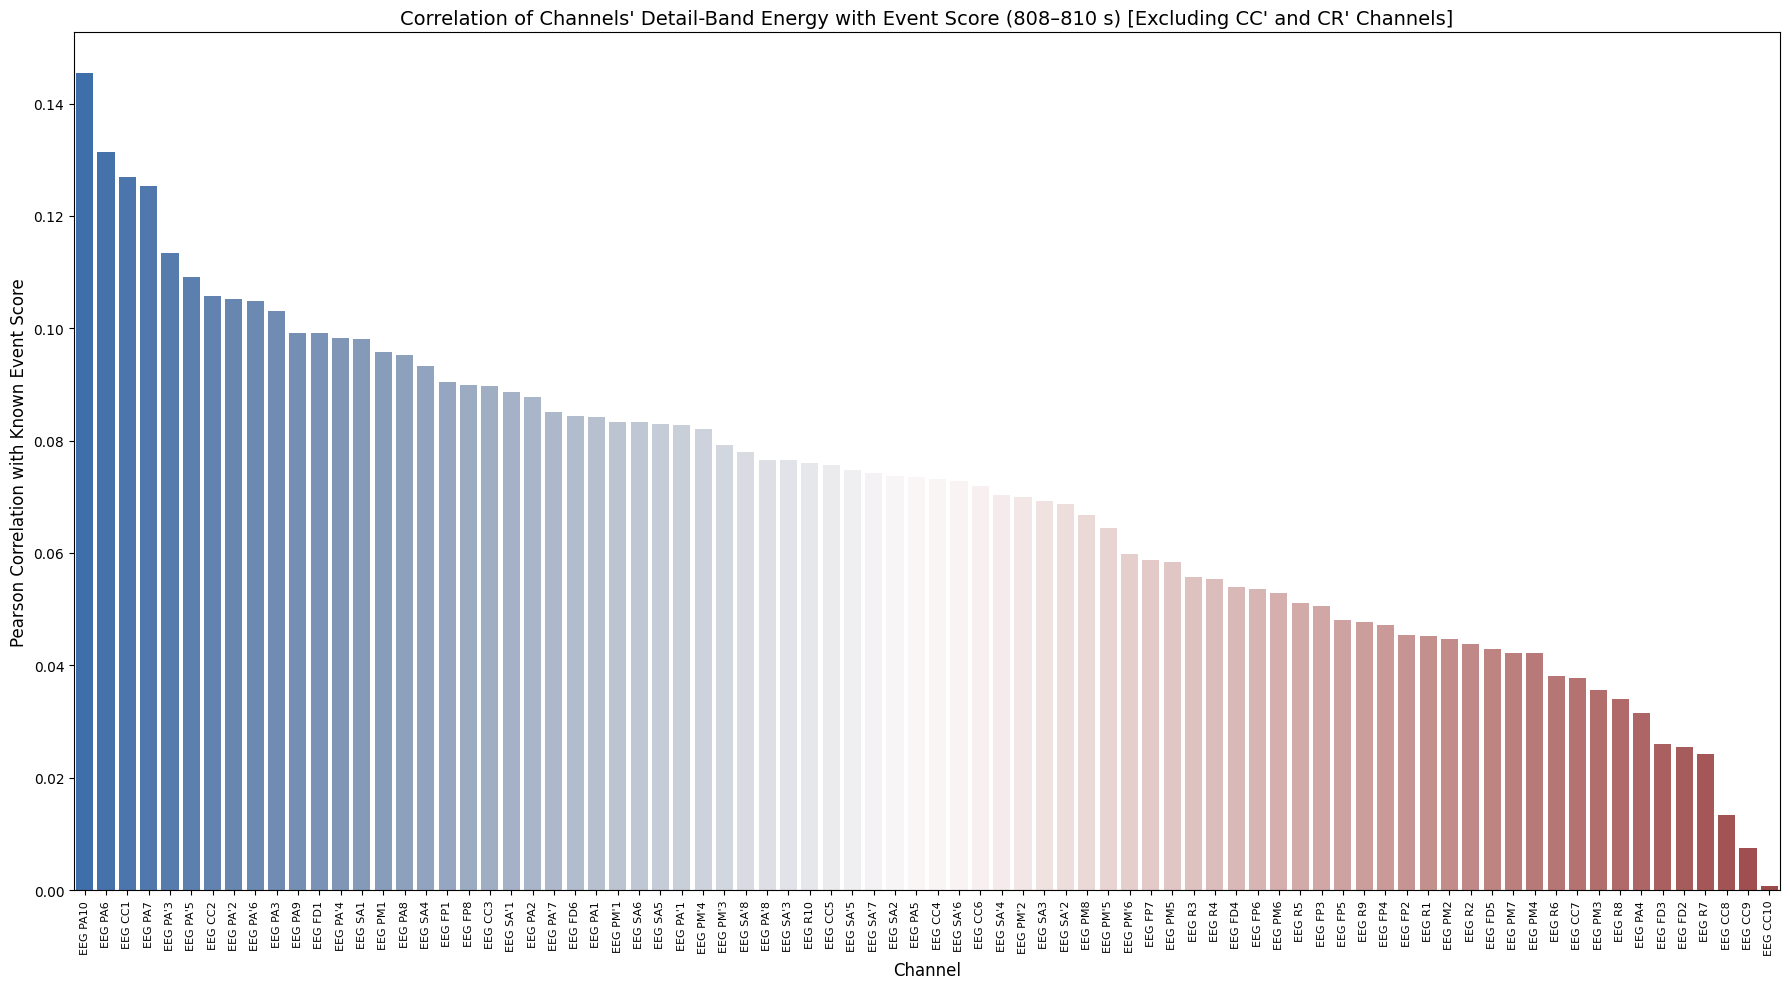


Top 10 channels positively correlated with the event score (excluding CC' and CR' channels):


,Channel,Correlation_with_Event_Score
57,EEG PA10,0.145398
53,EEG PA6,0.131381
32,EEG CC1,0.126972
54,EEG PA7,0.125337
74,EEG PA'3,0.113416
76,EEG PA'5,0.109198
33,EEG CC2,0.105715
73,EEG PA'2,0.105291
77,EEG PA'6,0.104884
50,EEG PA3,0.103041



Top 10 channels negatively correlated with the event score (excluding CC' and CR' channels):


,Channel,Correlation_with_Event_Score
38,EEG CC7,0.037752
26,EEG PM3,0.035590
7,EEG R8,0.034049
51,EEG PA4,0.031514
20,EEG FD3,0.025926
19,EEG FD2,0.025500
6,EEG R7,0.024183
39,EEG CC8,0.013411
40,EEG CC9,0.007421
41,EEG CC10,0.000733


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Assuming node_features, event_score, seeg_channels, wavelet_energy_feature_count are available
# from previous cells.

# Define the slice for detail-band energy features, consistent with event_score calculation
# wavelet_energy_feature_count was 6, so detail_energy_slice is from index 1 to 5 (exclusive of 6)
detail_energy_slice = slice(1, wavelet_energy_feature_count)

# Dynamically identify channels to exclude based on the patterns CC'{i} and CR'{i}
exclude_pattern = re.compile(r"^EEG (CC|CR)'\d+$", flags=re.IGNORECASE)
channels_to_exclude_from_correlation = [
    ch for ch in seeg_channels if exclude_pattern.fullmatch(ch.strip())
]

# Calculate correlations for all channels with the known event score
correlations_with_event_score = {}
for i, channel_name in enumerate(seeg_channels):
    # Exclude channels matching the CC'{i} and CR'{i} patterns from this correlation evaluation
    if channel_name in channels_to_exclude_from_correlation:
        continue

    # Extract the mean detail-band log energy for the current channel across all windows
    # node_features has shape [window, channel, feature]
    channel_detail_energy_series = node_features[:, i, detail_energy_slice].mean(dim=1)

    # Calculate Pearson correlation
    # Convert to numpy for np.corrcoef and ensure both series are 1D
    correlation = np.corrcoef(channel_detail_energy_series.numpy(), event_score.numpy())[0, 1]
    correlations_with_event_score[channel_name] = correlation

# Convert to DataFrame for easier plotting and analysis
correlation_df = pd.DataFrame(
    list(correlations_with_event_score.items()),
    columns=['Channel', 'Correlation_with_Event_Score']
)

# Sort by correlation for better visualization
correlation_df = correlation_df.sort_values(by='Correlation_with_Event_Score', ascending=False)

# Visualize the correlations
plt.figure(figsize=(18, 10))
sns.barplot(x='Channel', y='Correlation_with_Event_Score', data=correlation_df, palette='vlag', width=0.8)
plt.xticks(rotation=90, fontsize=8) # Rotate labels for readability
plt.yticks(fontsize=10)
plt.xlabel("Channel", fontsize=12)
plt.ylabel("Pearson Correlation with Known Event Score", fontsize=12)
plt.title("Correlation of Channels' Detail-Band Energy with Event Score (808–810 s) [Excluding CC' and CR' Channels]", fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line for reference
plt.tight_layout()
plt.show()

# Display the top and bottom correlated channels
print("\nTop 10 channels positively correlated with the event score (excluding CC' and CR' channels):")
display(correlation_df.head(10))
print("\nTop 10 channels negatively correlated with the event score (excluding CC' and CR' channels):")
display(correlation_df.tail(10))

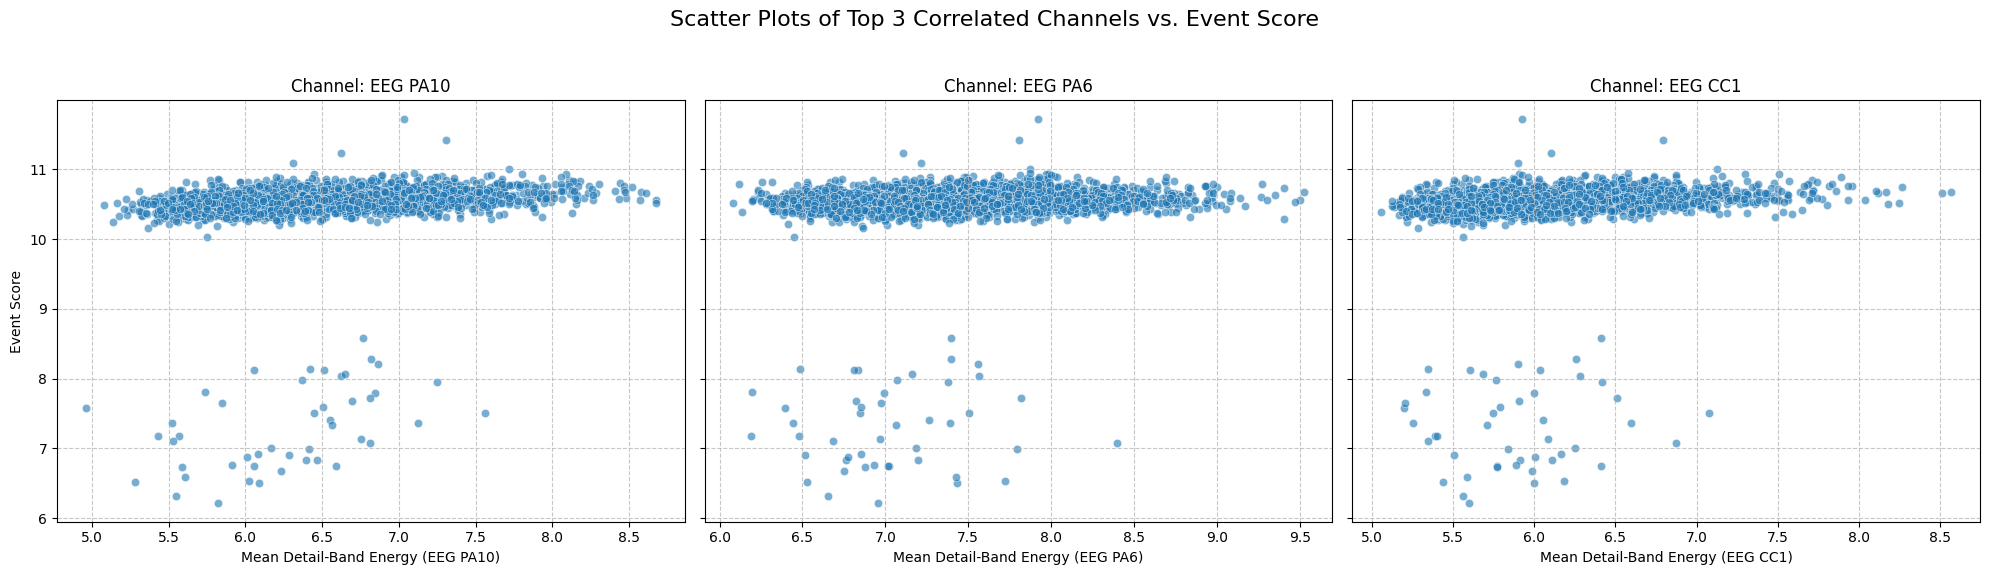

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 3 positively correlated channels
top_3_channels = correlation_df.head(3)['Channel'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Scatter Plots of Top 3 Correlated Channels vs. Event Score', fontsize=16)

for i, channel_name in enumerate(top_3_channels):
    ax = axes[i]
    # Find the index of the channel in seeg_channels
    channel_idx = seeg_channels.index(channel_name)

    # Extract the mean detail-band log energy for the current channel across all windows
    channel_detail_energy_series = node_features[:, channel_idx, detail_energy_slice].mean(dim=1)

    sns.scatterplot(x=channel_detail_energy_series.numpy(), y=event_score.numpy(), ax=ax, alpha=0.6)
    ax.set_title(f'Channel: {channel_name}')
    ax.set_xlabel(f'Mean Detail-Band Energy ({channel_name})')
    if i == 0: # Only set ylabel for the first subplot to avoid redundancy with sharey=True
        ax.set_ylabel('Event Score')
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()